--- Primeras Filas ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


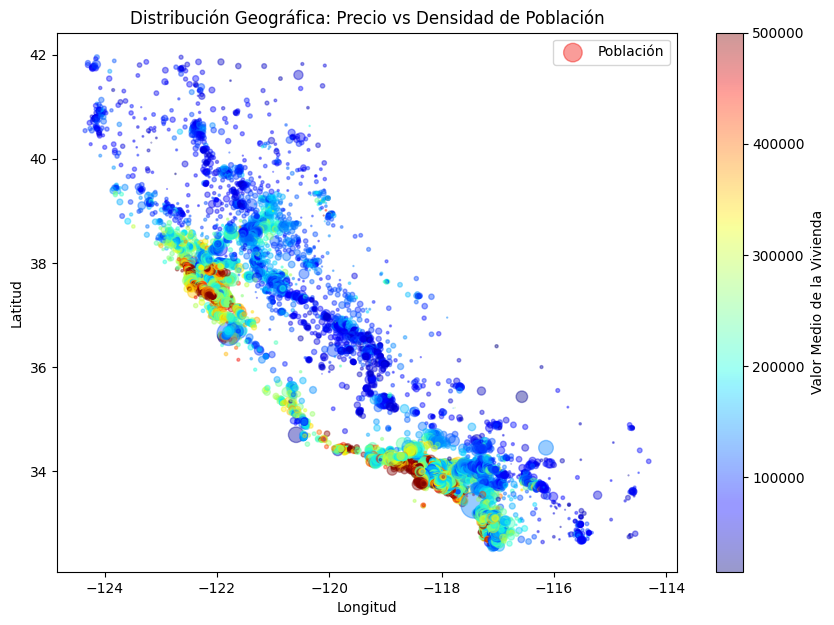

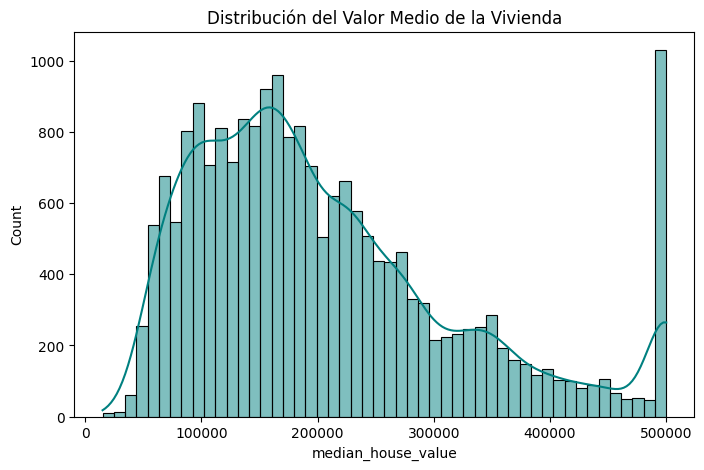


--- Correlación con median_house_value ---
median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

Forma de los datos preparados: (16512, 16)

--- Resultados del Modelo Base ---
Root Mean Squared Error (RMSE): $69,127.04
R2 Score: 0.6353


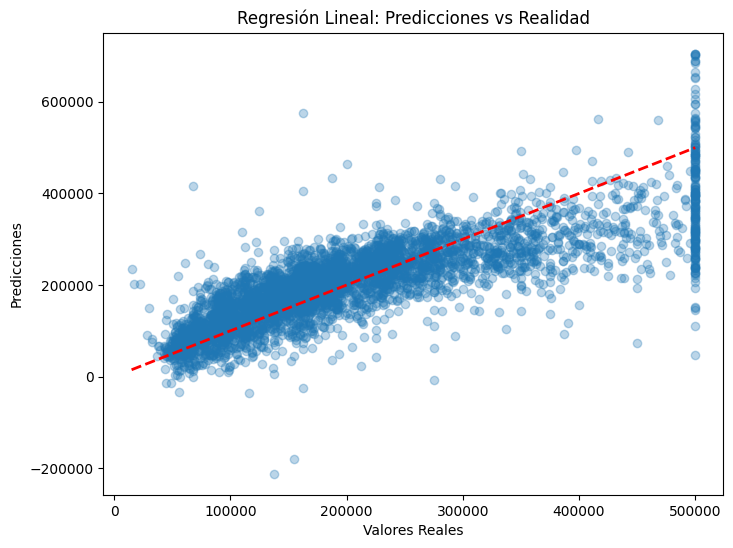

In [2]:
# -*- coding: utf-8 -*-
"""
Análisis Exploratorio de Datos (EDA) y Preparación para Modelado Predictivo
Dataset: California Housing
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Carga de datos
df = pd.read_csv('../data/housing.csv')

# --- PARTE 1: ANÁLISIS EXPLORATORIO DE DATOS (EDA) ---

print("--- Primeras Filas ---")
display(df.head())

print("\n--- Información General ---")
df.info()

# Visualización Geográfica
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['longitude'], df['latitude'], alpha=0.4,
            s=df['population']/100, label='Población',
            c=df['median_house_value'], cmap=plt.get_cmap('jet'))
plt.colorbar(sc, label='Valor Medio de la Vivienda')
plt.title('Distribución Geográfica: Precio vs Densidad de Población')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.show()

# Distribución de la variable objetivo
plt.figure(figsize=(8, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='teal')
plt.title('Distribución del Valor Medio de la Vivienda')
plt.show()

# --- PARTE 2: INGENIERÍA DE ATRIBUTOS (FEATURE ENGINEERING) ---

# Creamos variables que aportan más contexto que los totales por bloque
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# Ver correlación con la variable objetivo
corr_matrix = df.corr(numeric_only=True)
print("\n--- Correlación con median_house_value ---")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

# --- PARTE 3: PREPARACIÓN DE DATOS PARA MACHINE LEARNING ---

# Separar predictores y variable objetivo
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"].copy()

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir columnas por tipo
num_attribs = X.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs = ["ocean_proximity"]

# Crear Pipeline para datos numéricos: Imputación + Escalado
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")), # Manejo de nulos en total_bedrooms
    ('std_scaler', StandardScaler()),              # Normalización
])

# Combinar transformaciones (Numéricas y Categóricas)
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# Aplicar transformaciones
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print(f"\nForma de los datos preparados: {X_train_prepared.shape}")

# --- PARTE 4: MODELADO BÁSICO (REGRESIÓN LINEAL) ---

lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

# Evaluación
predictions = lin_reg.predict(X_test_prepared)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\n--- Resultados del Modelo Base ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

# Visualización de Predicciones vs Valores Reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal: Predicciones vs Realidad')
plt.show()